<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 7 — Redes Neuronales Convolucionales para Imágenes Biomédicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

> **Nota para estudiantes:** las celdas con `TODO` indican exactamente qué deben completar. Las pistas orientan el razonamiento, pero no reemplazan la interpretación clínica.


## Contexto clínico

En el Challenge 6 entrenaste un **perceptrón** y un **MLP** usando variables tabulares del dataset Breast Cancer Wisconsin. Ahora pasamos de datos tabulares a **imágenes biomédicas**.

Trabajaremos con **PneumoniaMNIST**, un dataset de imágenes de radiografía de tórax en escala de grises, reducido a 28×28 píxeles, con dos clases:

- `0 = Normal`
- `1 = Pneumonia`

El objetivo será entrenar modelos en **PyTorch** para distinguir entre radiografías normales y radiografías con neumonía. Primero construiremos un **baseline MLP** que aplana la imagen y luego una **CNN** que conserva la estructura espacial.

**Pregunta clínica:** ¿por qué una CNN debería ser más adecuada que un MLP cuando la entrada es una imagen? ¿Qué error clínico es más crítico: clasificar una neumonía como normal o clasificar un caso normal como neumonía?

---
> **Dataset:** PneumoniaMNIST, colección MedMNIST.  
> Se descarga directamente desde Python usando la librería `medmnist`.


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
🧑‍🎓 <b>VERSIÓN ESTUDIANTE</b> — completa los espacios en blanco, ejecuta el notebook en orden y responde las preguntas de interpretación clínica.
</div>


---
## Ejercicio 1 — Diseño previo al código

### 1.1 — De MLP a CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde antes de programar
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué problema tiene usar un MLP directamente sobre una imagen?**  
El MLP no procesa bien las imágenes espaciales ni la vecindad de los piceles, por lo que se pierden estos datos.

---

**2. ¿Qué ventaja tiene una CNN?**  
CNN tiene comparación de pesos e invarianza a la traslación, por lo que pueden detectar patrones que se encuentren en las imágenes

---

**3. ¿Qué podría representar un filtro convolucional en una radiografía de tórax?**  
En las primeras convoluciones, el filtro detecta bordes y contrastes, en las capas más profundas detecta patrones más complejos, como lesiones pulmonares.


### 1.2 — Convolución, pooling y clasificación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde con tus palabras
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué produce una capa convolucional?**  
Una capa produce un mapa de característica, que se generan cuando un filtro se desliza sobre la entrada.

**2. ¿Para qué sirve MaxPooling?**  
Sirve para reducir las dimensiones espaciales de los mapas de características, haciendolo más sensible a pequeñas deformaciones

**3. ¿Por qué al final usamos una capa lineal?**  
Se usa la capa lineal ya que conecta todas las características espaciales compactas y las mapea hacia un único valor

**4. ¿Por qué seguimos usando `BCEWithLogitsLoss`?**  
Por que el problema a resolver es de clasificación binaria, además, esta función estabiliza muméricamete el modelo.


### 1.3 — Pipeline completo

**TODO:** completa cada paso del pipeline con una frase breve.

Completa el siguiente pipeline:

```text
PneumoniaMNIST
      │
      ▼
[ Paso A ] Setup y carga de datos

      │
      ▼
[ Paso B ] DataLoaders Eficientes (batches)
      │
      ▼
[ Paso C ] MLP baseline
      │
      ▼
[ Paso D ] CNN
      │
      ▼
[ Paso E ] Funciones reutilizables de entrenamiento
      │
      ▼
[ Paso F ] Entrenamiento
      │
      ▼
[ Paso G ] Extracción de probabilidades en Test
      │
      ▼
[ Paso H ] Métricas
```

**📝 Pregunta:** ¿por qué conviene entrenar primero un MLP baseline antes de entrenar la CNN?  
Conviene primero entrenar un MLP para tener un punto de comparación con el CNN y saber que se justifica su uso.

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 2.1 — Librerías

In [1]:
# ── Instalación robusta de MedMNIST ─────────────────────────────
# En Google Colab debería ejecutarse sin problemas.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("medmnist") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

# ── Colores institucionales UPCH ───────────────────────────────
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

# ── Librerías base ──────────────────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

# ── Dataset MedMNIST ────────────────────────────────────────────
from medmnist import PneumoniaMNIST, INFO

# ── Métricas ────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (7, 4)

def seed_everything(seed=42):
    """Fija semillas para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Paso 2.2 — Transformaciones y carga de PneumoniaMNIST

In [2]:
# ── Información del dataset ─────────────────────────────────────
info = INFO['pneumoniamnist']
print("Descripción:", info['description'][:300], "...")
print("Clases:", info['label'])
print("Canales:", info['n_channels'])

# ── Transformación: PIL/NumPy → Tensor normalizado ──────────────
# TODO 1: completa mean y std para una imagen en escala de grises.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# ── Carga de splits oficiales ───────────────────────────────────
train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=transform, download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=transform, download=True)

print(f"Train: {len(train_dataset)} imágenes")
print(f"Val:   {len(val_dataset)} imágenes")
print(f"Test:  {len(test_dataset)} imágenes")

sample_img, sample_label = train_dataset[0]
print("Forma de una imagen:", sample_img.shape)
print("Etiqueta ejemplo:", int(sample_label[0]))


Descripción: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The sour ...
Clases: {'0': 'normal', '1': 'pneumonia'}
Canales: 1


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.34MB/s]


Train: 4708 imágenes
Val:   524 imágenes
Test:  624 imágenes
Forma de una imagen: torch.Size([1, 28, 28])
Etiqueta ejemplo: 1


### Paso 2.3 — Distribución de clases y visualización inicial

class_name,Normal,Pneumonia
split,,
test,234,390
train,1214,3494
val,135,389


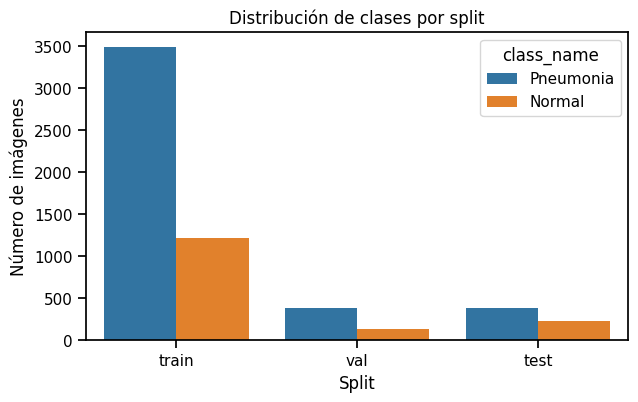

In [3]:
# ── Distribución de clases ──────────────────────────────────────
label_map = {0: "Normal", 1: "Pneumonia"}

def get_label_array(dataset):
    return dataset.labels.reshape(-1).astype(int)

train_labels = get_label_array(train_dataset)
val_labels   = get_label_array(val_dataset)
test_labels  = get_label_array(test_dataset)

dist_df = pd.DataFrame({
    "split": ["train"] * len(train_labels) + ["val"] * len(val_labels) + ["test"] * len(test_labels),
    "label": np.concatenate([train_labels, val_labels, test_labels])
})
dist_df["class_name"] = dist_df["label"].map(label_map)

display(pd.crosstab(dist_df["split"], dist_df["class_name"]))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=dist_df, x="split", hue="class_name", ax=ax)
ax.set_title("Distribución de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Número de imágenes")
plt.show()

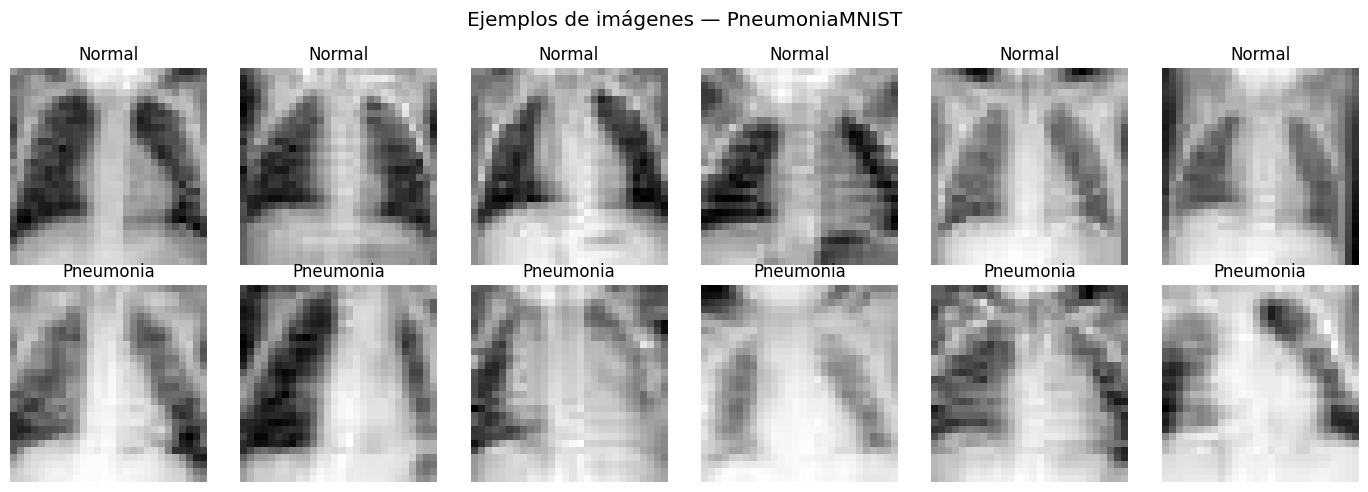

In [4]:
# ── Visualización de ejemplos ───────────────────────────────────
def unnormalize_img(img_tensor):
    """Convierte tensor normalizado [-1,1] a imagen [0,1] para visualizar."""
    return (img_tensor.squeeze().cpu().numpy() * 0.5) + 0.5

def plot_class_examples(dataset, n_per_class=6):
    labels = get_label_array(dataset)
    fig, axes = plt.subplots(2, n_per_class, figsize=(14, 5))

    for class_id in [0, 1]:
        idxs = np.where(labels == class_id)[0]
        chosen = np.random.choice(idxs, size=n_per_class, replace=False)

        for j, idx in enumerate(chosen):
            img, label = dataset[idx]
            axes[class_id, j].imshow(unnormalize_img(img), cmap="gray")
            axes[class_id, j].axis("off")
            axes[class_id, j].set_title(label_map[int(label[0])])

    plt.suptitle("Ejemplos de imágenes — PneumoniaMNIST")
    plt.tight_layout()
    plt.show()

plot_class_examples(train_dataset, n_per_class=6)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué forma tiene cada imagen y qué significa cada dimensión?**  
Para que las imágenes entren al sistema, deben tener la forma de un tensor de PyTorch con las dimensiones [1, 28, 28].
El [1] significa que solo se tiene un canal de color, ya que la imágen es a blanco y negro
[28, 28] es por la altura y el ancho de la imagen respectivamente, teniendo esta forma cuadrada.

**2. ¿Observas desbalance de clases? ¿Por qué importa?**  
Si se ve un gran desbalance con la mayoría de datos siendo de Pneumonia, esto importa por que el sistema va a tener una "preferencia" por el sistema con más muestras

**3. En este problema, ¿qué sería un falso negativo?**  
Un falso negativo es aquel que fue predicho ser negativo (NORMAL) pero en realidad no era negativo, era positivo (PNEUMONIA). Por lo que una persona con la enfermedad fue incorrectamente clasificada

**4. ¿Por qué una CNN puede ser apropiada para este tipo de dato?**  
Primero por el tipo de entrada de datos, estos son estructuras espaciales, ademas, por que van a poder detectar las lesiones pulmonares sin importar el lugar donde esten en el pulmón ni el tamaño que tenga esta.


---
# PARTE 1 — DataLoader y mini-batches de imágenes
## Ejercicio 3 — Preparación de mini-batches

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Creación de DataLoaders

In [6]:
# ── DataLoaders ─────────────────────────────────────────────────
# TODO 2: define un tamaño de mini-batch y el orden de mezcla.
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=___,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=___, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=___, num_workers=0)

xb, yb = next(iter(train_loader))

print("Mini-batch de imágenes:", xb.shape)
print("Mini-batch de etiquetas:", yb.shape)
print("Tipo de dato X:", xb.dtype)
print("Tipo de dato y:", yb.dtype)


Mini-batch de imágenes: torch.Size([128, 1, 28, 28])
Mini-batch de etiquetas: torch.Size([128, 1])
Tipo de dato X: torch.float32
Tipo de dato y: torch.int64


### Paso 3.2 — ¿Qué significa la forma del tensor?

In [7]:
# ── Interpretación de dimensiones ───────────────────────────────
# TODO 3: completa los prints usando las variables B, C, H y W.
B, C, H, W = xb.shape
print(f"B = {B} imágenes por mini-batch")
print(f"C = {C} canal(es) de imagen")
print(f"H = {H} píxeles de alto")
print(f"W = {W} píxeles de ancho")


B = 128 imágenes por mini-batch
C = 1 canal(es) de imagen
H = 28 píxeles de alto
W = 28 píxeles de ancho


### Paso 3.3 — Interpretación

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué significa el formato `[batch, channels, height, width]`?**  
El formato es la jerarquía en la cual PyTprch empaqueta los datos de los tensores para entrar al modelo.

**2. ¿Por qué PneumoniaMNIST tiene un solo canal?**  
Solo tiene 1 canal por que la imagen es a blanco y negro, por lo que solo es 1 color, monocromático.

**3. ¿Por qué entrenamos con mini-batches en lugar de procesar todo el dataset de una sola vez?**  
Ya que van variando las 128 imágenes al azar, ayuda a entrenar el sistema unos mínimos locales y a encontrar mejores soluciones.

---
# PARTE 2 — Baseline MLP con imagen aplanada
## Ejercicio 4 — Modelo MLP para comparar contra CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 4.1 — Definición del baseline MLP

In [8]:
# ── Baseline: MLP que aplana la imagen ──────────────────────────
# TODO 4: completa las dimensiones del MLP.
class FlattenMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),  # TODO 4.1: capa de entrada → capa oculta
            nn.ReLU(),
            nn.Linear(64, 1)   # TODO 4.2: capa oculta → 1 logit
        )

    def forward(self, x):
        return self.net(x)

mlp_model = FlattenMLP().to(device)
print(mlp_model)


FlattenMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Paso 4.2 — Funciones generales de entrenamiento y evaluación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa el cálculo de desbalance y el ciclo de entrenamiento
</div>

**Nota:** `pos_weight` ayuda a manejar desbalance en la función de pérdida, pero la decisión clínica final se analiza con sensibilidad, especificidad y umbrales.


In [9]:
# ── Conteo de parámetros ────────────────────────────────────────
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Parámetros del MLP:", count_parameters(mlp_model))

# ── Peso para clase positiva por desbalance ─────────────────────
# TODO 5: cuenta positivos y negativos usando train_labels.
# En este dataset: 0 = Normal, 1 = Pneumonia.
n_pos = (train_labels == 1).sum()
n_neg = (train_labels == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

print(f"n_neg={n_neg}, n_pos={n_pos}, pos_weight={pos_weight.item():.3f}")

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        # TODO 6: forward pass → pérdida → backpropagation → actualización
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


def fit_model(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=6):
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc     = evaluate_one_epoch(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f}"
        )

    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], marker="o", label="train")
    axes[0].plot(history["val_loss"], marker="o", label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], marker="o", label="train")
    axes[1].plot(history["val_acc"], marker="o", label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Parámetros del MLP: 50305
n_neg=1214, n_pos=3494, pos_weight=0.347


### Paso 4.3 — Entrenamiento del MLP

Epoch 01/7 | train_loss=0.1627 | val_loss=0.0920 | train_acc=0.868 | val_acc=0.937
Epoch 02/7 | train_loss=0.0835 | val_loss=0.0779 | train_acc=0.937 | val_acc=0.948
Epoch 03/7 | train_loss=0.0722 | val_loss=0.0726 | train_acc=0.946 | val_acc=0.950
Epoch 04/7 | train_loss=0.0673 | val_loss=0.0707 | train_acc=0.949 | val_acc=0.950
Epoch 05/7 | train_loss=0.0642 | val_loss=0.0695 | train_acc=0.952 | val_acc=0.947
Epoch 06/7 | train_loss=0.0618 | val_loss=0.0686 | train_acc=0.954 | val_acc=0.945
Epoch 07/7 | train_loss=0.0597 | val_loss=0.0676 | train_acc=0.957 | val_acc=0.948


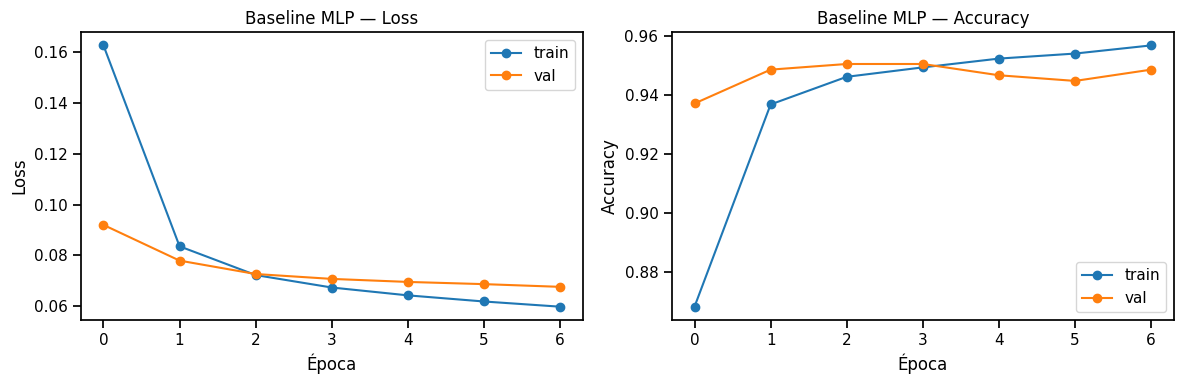

In [10]:
# ── Entrenamiento del baseline MLP ──────────────────────────────
# TODO 7: define learning rate y número de épocas.
#         Pista: empieza con lr=1e-3 y pocas épocas para que sea rápido en clase.
seed_everything(42)

mlp_model = FlattenMLP().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

mlp_history = fit_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=mlp_optimizer,
    device=device,
    epochs=7
)

plot_history(mlp_history, "Baseline MLP")


### Paso 4.4 — Interpretación del baseline

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué información espacial pierde el MLP al aplanar la imagen?**  
Al aplanar la imagen, se pierde la vecindad de pixeles, ahora se trabaja como una coordenada específica y aislada a cada dato

**2. ¿Por qué este MLP sirve como baseline y no necesariamente como mejor modelo final?**  
Sirve como baseline ya que nos da la base mínima de rendimiento pero no es el mejor modelo final ya que no trabaja con la vecindad que forma las opacidadespulmonares.


---
# PARTE 3 — CNN para clasificación de radiografías
## Ejercicio 5 — Modelo convolucional en PyTorch

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — Definición de la CNN

In [14]:
# ── CNN simple para imágenes 28×28 en escala de grises ──────────
# TODO 8: completa la arquitectura CNN.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),  # TODO 8.3,  # TODO 8.1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # TODO 8.4,  # TODO 8.2

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),  # TODO 8.5: flatten features → capa oculta
            nn.ReLU(),
            nn.Linear(64, 1)  # TODO 8.6: capa oculta → 1 logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN().to(device)
print(cnn_model)
print("Parámetros de la CNN:", count_parameters(cnn_model))


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros de la CNN: 105281


### Paso 5.2 — Verificación de dimensiones con un mini-batch

In [15]:
# ── Sanity check de dimensiones ─────────────────────────────────
# TODO 9: pasa el mismo mini-batch por extractor de características y modelo completo.
xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    feature_maps = cnn_model.features(xb)
    logits = cnn_model(xb)

print("Entrada:", xb.shape)
print("Después de convoluciones + pooling:", feature_maps.shape)
print("Salida logits:", logits.shape)


Entrada: torch.Size([128, 1, 28, 28])
Después de convoluciones + pooling: torch.Size([128, 32, 7, 7])
Salida logits: torch.Size([128, 1])


### Paso 5.3 — Entrenamiento de la CNN

Epoch 01/7 | train_loss=0.2335 | val_loss=0.1130 | train_acc=0.809 | val_acc=0.927
Epoch 02/7 | train_loss=0.1023 | val_loss=0.0939 | train_acc=0.919 | val_acc=0.903
Epoch 03/7 | train_loss=0.0863 | val_loss=0.0852 | train_acc=0.929 | val_acc=0.912
Epoch 04/7 | train_loss=0.0766 | val_loss=0.0827 | train_acc=0.939 | val_acc=0.918
Epoch 05/7 | train_loss=0.0705 | val_loss=0.0795 | train_acc=0.945 | val_acc=0.916
Epoch 06/7 | train_loss=0.0657 | val_loss=0.0769 | train_acc=0.951 | val_acc=0.924
Epoch 07/7 | train_loss=0.0616 | val_loss=0.0748 | train_acc=0.954 | val_acc=0.924


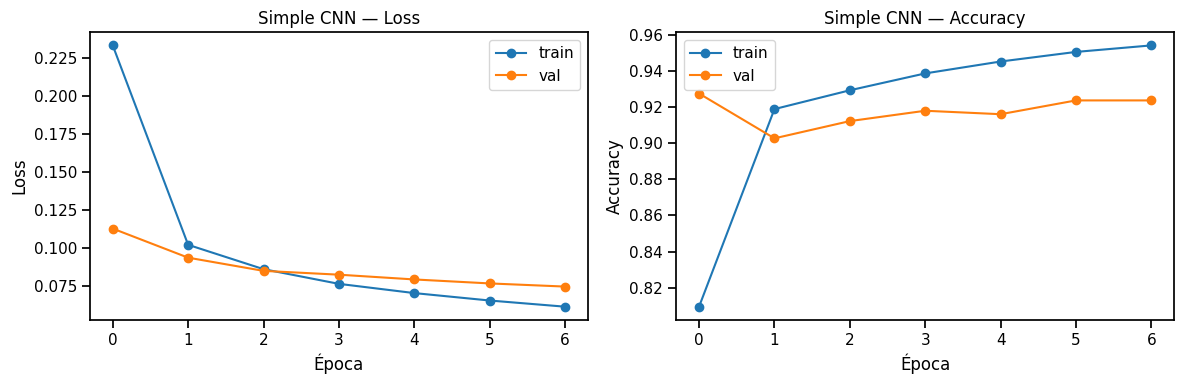

In [16]:
# ── Entrenamiento de la CNN ─────────────────────────────────────
# TODO 10: define learning rate y épocas para la CNN.
seed_everything(42)

cnn_model = SimpleCNN().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)

cnn_history = fit_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=cnn_optimizer,
    device=device,
    epochs=7
)

plot_history(cnn_history, "Simple CNN")


### Paso 5.4 — Comparación visual de curvas

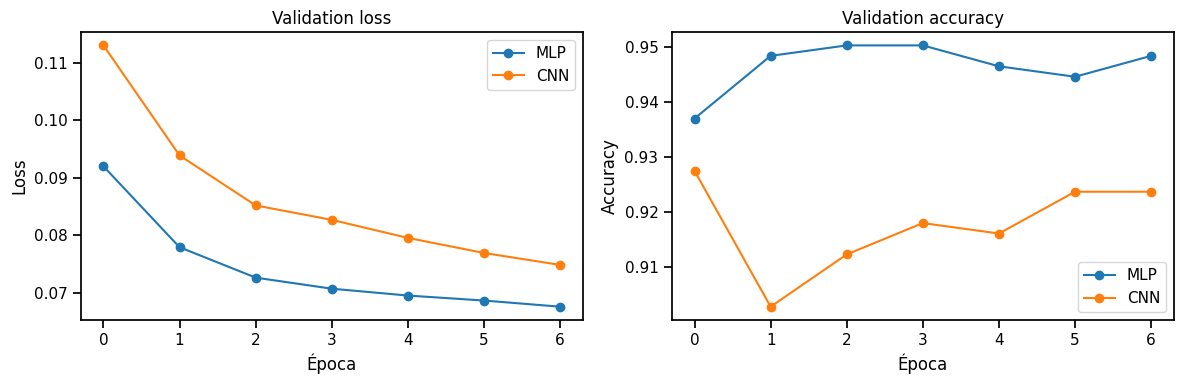

In [17]:
# ── Comparación de curvas MLP vs CNN ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_history["val_loss"], marker="o", label="MLP")
axes[0].plot(cnn_history["val_loss"], marker="o", label="CNN")
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(mlp_history["val_acc"], marker="o", label="MLP")
axes[1].plot(cnn_history["val_acc"], marker="o", label="CNN")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Paso 5.5 — Interpretación CNN vs MLP

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿La CNN mejora frente al MLP? Usa tus curvas y métricas, no solo accuracy.**  
La CNN no mejora, el validation loss es más alto y el validation accuracy es mucho menor

**2. ¿Qué aporta la convolución que no aporta el MLP al aplanar la imagen?**  
La convolución hace una extracción de características locales usando los kernels, al aplanar la imagen, se pierde esto y solo se trabaja con coordenadas.

**3. Si la CNN tiene mejor AUC o especificidad, pero menor sensibilidad con umbral 0.5, ¿cómo interpretarías ese resultado?**  
La especificidad de esta CNN indicaría que clasifica entre las 2 clases correctamente, pero debido al umbral de sensibilidad, indica que no esta identificando correctamente a personas enfermas.

**4. ¿Qué factores podrían explicar que una CNN simple no mejore mucho frente al baseline?**  
Puede deberse a que se ha quedado en un nivel muy superficial en el que solo reconoce bordes y contrastes pero no algún patrón relevante

---
# PARTE 4 — Métricas clínicas y análisis de errores
## Ejercicio 6 — Evaluación final

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Predicción de probabilidades

In [18]:
# ── Predicción de probabilidades en test ────────────────────────
# TODO 11: convierte logits en probabilidades con sigmoid.
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()

    all_probs = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs)
        all_true.extend(y_batch.numpy().reshape(-1).astype(int))

    return np.array(all_true), np.array(all_probs)

y_test_true, mlp_prob = predict_proba(mlp_model, test_loader, device)
_, cnn_prob = predict_proba(cnn_model, test_loader, device)

print("Primeras probabilidades MLP:", mlp_prob[:5])
print("Primeras probabilidades CNN:", cnn_prob[:5])


Primeras probabilidades MLP: [[0.9997477 ]
 [0.9994579 ]
 [0.95513415]
 [0.00180072]
 [0.99948704]]
Primeras probabilidades CNN: [[9.9904662e-01]
 [9.9856323e-01]
 [7.0361400e-01]
 [7.7664852e-04]
 [9.9885321e-01]]


### Paso 6.2 — Métricas clínicas

In [19]:
# ── Métricas clínicas ───────────────────────────────────────────
# TODO 12: completa sensibilidad, especificidad y precisión.
def clinical_metrics(y_true, y_prob, threshold=0.5, model_name="model"):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = pd.DataFrame([
    clinical_metrics(y_test_true, mlp_prob, threshold=0.5, model_name="MLP"),
    clinical_metrics(y_test_true, cnn_prob, threshold=0.5, model_name="CNN")
])

display(results)


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,roc_auc,TN,FP,FN,TP
0,MLP,0.5,0.873397,0.971795,0.709402,0.847875,0.905615,0.922737,166,68,11,379
1,CNN,0.5,0.886218,0.930769,0.811966,0.891892,0.910916,0.931065,190,44,27,363


### Paso 6.3 — Matrices de confusión

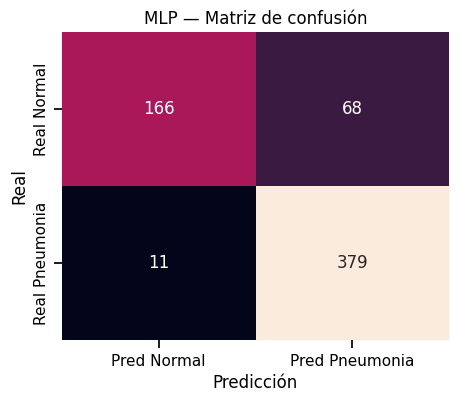

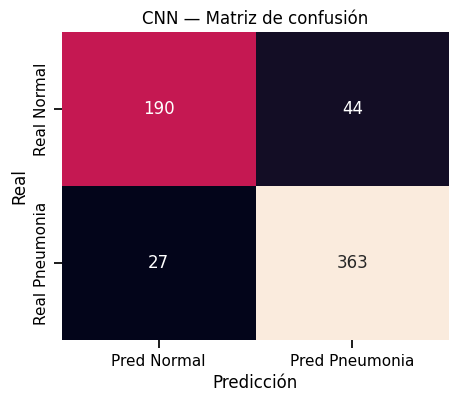

In [20]:
# ── Matrices de confusión ───────────────────────────────────────
def plot_confusion(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cbar=False,
        xticklabels=["Pred Normal", "Pred Pneumonia"],
        yticklabels=["Real Normal", "Real Pneumonia"],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.show()

plot_confusion(y_test_true, mlp_prob, threshold=0.5, title="MLP — Matriz de confusión")
plot_confusion(y_test_true, cnn_prob, threshold=0.5, title="CNN — Matriz de confusión")

### Paso 6.4 — Curva ROC

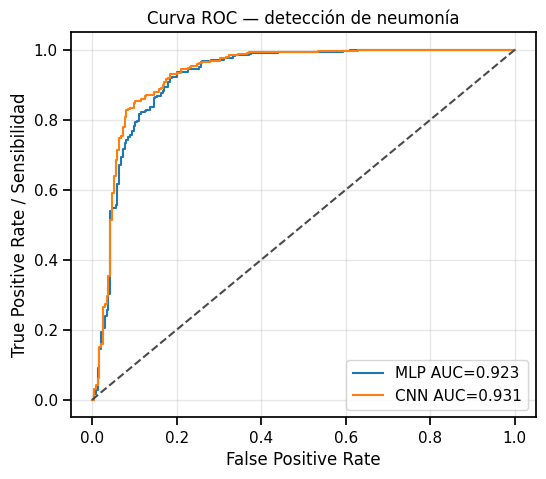

In [21]:
# ── Curva ROC ───────────────────────────────────────────────────
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_true, mlp_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_true, cnn_prob)

auc_mlp = roc_auc_score(y_test_true, mlp_prob)
auc_cnn = roc_auc_score(y_test_true, cnn_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_mlp, tpr_mlp, label=f"MLP AUC={auc_mlp:.3f}")
ax.plot(fpr_cnn, tpr_cnn, label=f"CNN AUC={auc_cnn:.3f}")
ax.plot([0, 1], [0, 1], "--", color=UPCH_GRAY)
ax.set_title("Curva ROC — detección de neumonía")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Sensibilidad")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Paso 6.5 — Análisis de umbral para la CNN

Un modelo produce probabilidades, pero la etiqueta final depende del **umbral de decisión**. En problemas clínicos, este umbral no siempre debe ser 0.5.

**Pregunta guía:** si el objetivo clínico es reducir falsos negativos, ¿qué umbral recomendarías y qué costo tendría en falsos positivos?


In [22]:
# ── Análisis de umbral ──────────────────────────────────────────
# TODO 13: prueba tres umbrales: bajo, estándar y alto.
threshold_rows = []
for th in [0.2, 0.5, 0.8]:
    threshold_rows.append(
        clinical_metrics(y_test_true, cnn_prob, threshold=th, model_name="CNN")
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[[
    "model", "threshold", "accuracy", "sensitivity_recall",
    "specificity", "precision", "f1", "FN", "FP", "TP", "TN"
]])


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,FN,FP,TP,TN
0,CNN,0.2,0.866987,0.969231,0.696581,0.841871,0.901073,12,71,378,163
1,CNN,0.5,0.886218,0.930769,0.811966,0.891892,0.910916,27,44,363,190
2,CNN,0.8,0.866987,0.858974,0.880342,0.922865,0.889774,55,28,335,206


### Paso 6.6 — Visualización de errores

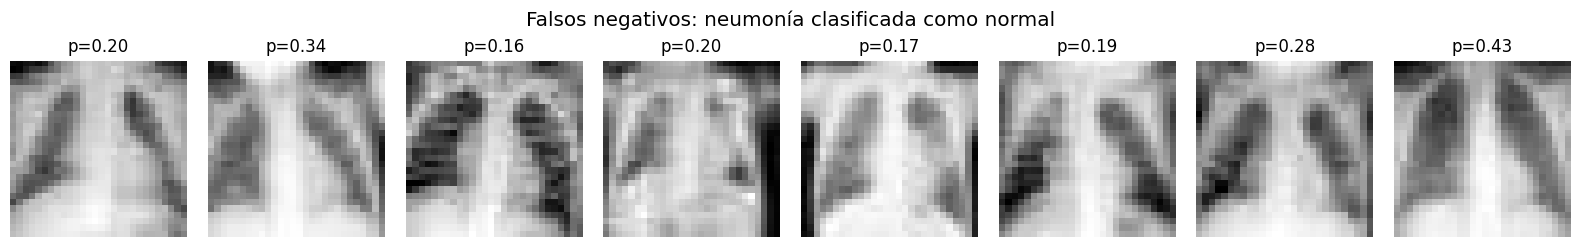

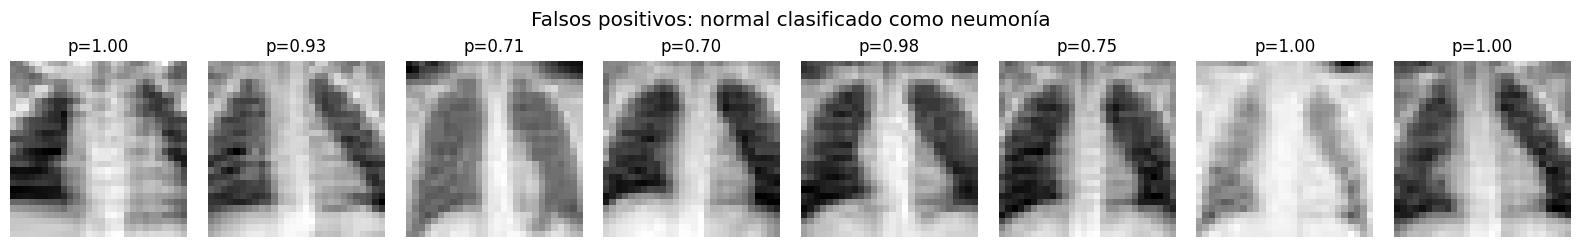

In [23]:
# ── Visualización de falsos negativos y falsos positivos ────────
@torch.no_grad()
def collect_images_probs(model, loader, device):
    model.eval()

    images = []
    y_true = []
    y_prob = []

    for X_batch, y_batch in loader:
        logits = model(X_batch.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

        images.append(X_batch.cpu())
        y_true.extend(y_batch.numpy().reshape(-1).astype(int))
        y_prob.extend(probs)

    images = torch.cat(images, dim=0)
    return images, np.array(y_true), np.array(y_prob)


def plot_errors(model, loader, device, error_type="FN", threshold=0.5, max_images=8):
    images, y_true, y_prob = collect_images_probs(model, loader, device)
    y_pred = (y_prob >= threshold).astype(int)

    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        title = "Falsos negativos: neumonía clasificada como normal"
    elif error_type == "FP":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        title = "Falsos positivos: normal clasificado como neumonía"
    else:
        raise ValueError("error_type debe ser 'FN' o 'FP'")

    if len(idxs) == 0:
        print(f"No se encontraron errores tipo {error_type} con threshold={threshold}.")
        return

    chosen = idxs[:max_images]

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        ax.imshow(unnormalize_img(images[idx]), cmap="gray")
        ax.axis("off")
        ax.set_title(f"p={y_prob[idx]:.2f}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_errors(cnn_model, test_loader, device, error_type="FN", threshold=0.5, max_images=8)
plot_errors(cnn_model, test_loader, device, error_type="FP", threshold=0.5, max_images=8)

### Paso 6.7 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué modelo elegirías como apoyo diagnóstico: MLP o CNN? Justifica con métricas.**  
Elegiría el CNN con umbral 0.2 ya que logra tener una mayor sensibilidad, por lo que detecta mejor los casos de personas enfermas

**2. ¿Qué métrica priorizarías si quieres reducir neumonías no detectadas?**  
Priorizaria la sensibilidad ya que mide precisamente este factor

**3. ¿Qué pasa con falsos positivos y falsos negativos al bajar el umbral?**  
Al bajar el umbral, el modelo es más sensible, por lo que los falsos negativos bajarían significativamente, pero en consecuencia, los falsos positivos subirían, generando errores de clasificación en pacientes sanos.

**4. ¿Qué umbral recomendarías para la CNN si el objetivo es reducir falsos negativos? Justifica con la tabla.**  
Recomendaría el de 0.2 ya que tiene la mayor sensibilidad (0.969231) mientras que los CNN con mayor umbral no pasan del (0.94)

**5. ¿Por qué este modelo no debe interpretarse como reemplazo del médico?**  
No se usaría como reemplazo ya que tiene muchas fallas en su accuracy y especificidad.


## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [ ] Respuestas conceptuales completas sobre MLP vs CNN, convolución, pooling y clasificación binaria.
- [ ] Carga correcta de PneumoniaMNIST con splits train/validation/test.
- [ ] Visualización de ejemplos de ambas clases.
- [ ] Creación correcta de DataLoaders con mini-batches.
- [ ] Definición funcional de `FlattenMLP`.
- [ ] Definición funcional de `SimpleCNN`.
- [ ] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [ ] Curvas de pérdida y accuracy para MLP y CNN.
- [ ] Evaluación en test con matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [ ] Análisis de umbral para la CNN.
- [ ] Discusión clínica de falsos negativos y falsos positivos.
- [ ] Conclusión comparando MLP vs CNN.
